# Particle Filter Testing

Tests across three state-space models:
1. `SimpleLinearGaussianSSM` — single filter run, MC RMSE distribution, noise sensitivity, resampling method comparison
2. `LinearTSSM` — correct vs misspecified (Gaussian) filter on t-distributed data
3. `LinearARMASSM` — filter on ARMA(1,3) latent process

In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from models.linear_gaussian import SimpleLinearGaussianSSM
from models.linear_t import LinearTSSM
from models.linear_ARMA import LinearARMASSM
from estimation.particle_filter import ParticleFilter
from estimation.resampling_methods import (
    SystematicResampling, MultinomialResampling, ResidualResampling, StratifiedResampling
)
from utils import filtered_trajectory, ess_trajectory, rmse

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

---
## 1. SimpleLinearGaussianSSM — single run

In [3]:
# true params
phi_true    = 0.9
alpha_true  = 1.5
sigma2_true = 0.25   # process noise variance  (sigma_std = 0.5)
tau2_true   = 1.0    # observation noise variance  (tau_std = 1.0)

model = SimpleLinearGaussianSSM(phi=phi_true, alpha=alpha_true,
                                sigma2=sigma2_true, tau2=tau2_true, seed=42)
print(model)

T = 200
states, observations, true_loglik = model.generate_data(T)
obs_1d = observations[:, 0]
true_x  = states[:, 0]

pf = ParticleFilter(
    model=model, N_particles=2000, data=obs_1d,
    resample_method=SystematicResampling(seed=0)
)
_, ph, wh, rsh, loglik = pf.run_filter()

x_hat = filtered_trajectory(pf)
print(f"True log-lik : {float(np.squeeze(true_loglik)):.2f}")
print(f"PF log-lik   : {loglik:.2f}")
print(f"RMSE         : {rmse(true_x, x_hat):.4f}")


SimpleLinearGaussianSSM(phi=0.9, alpha=1.5, sigma2=0.25, tau2=1.0)
ParticleFilter.run_filter  4.202s
True log-lik : -267.41
PF log-lik   : -342.23
RMSE         : 0.4068


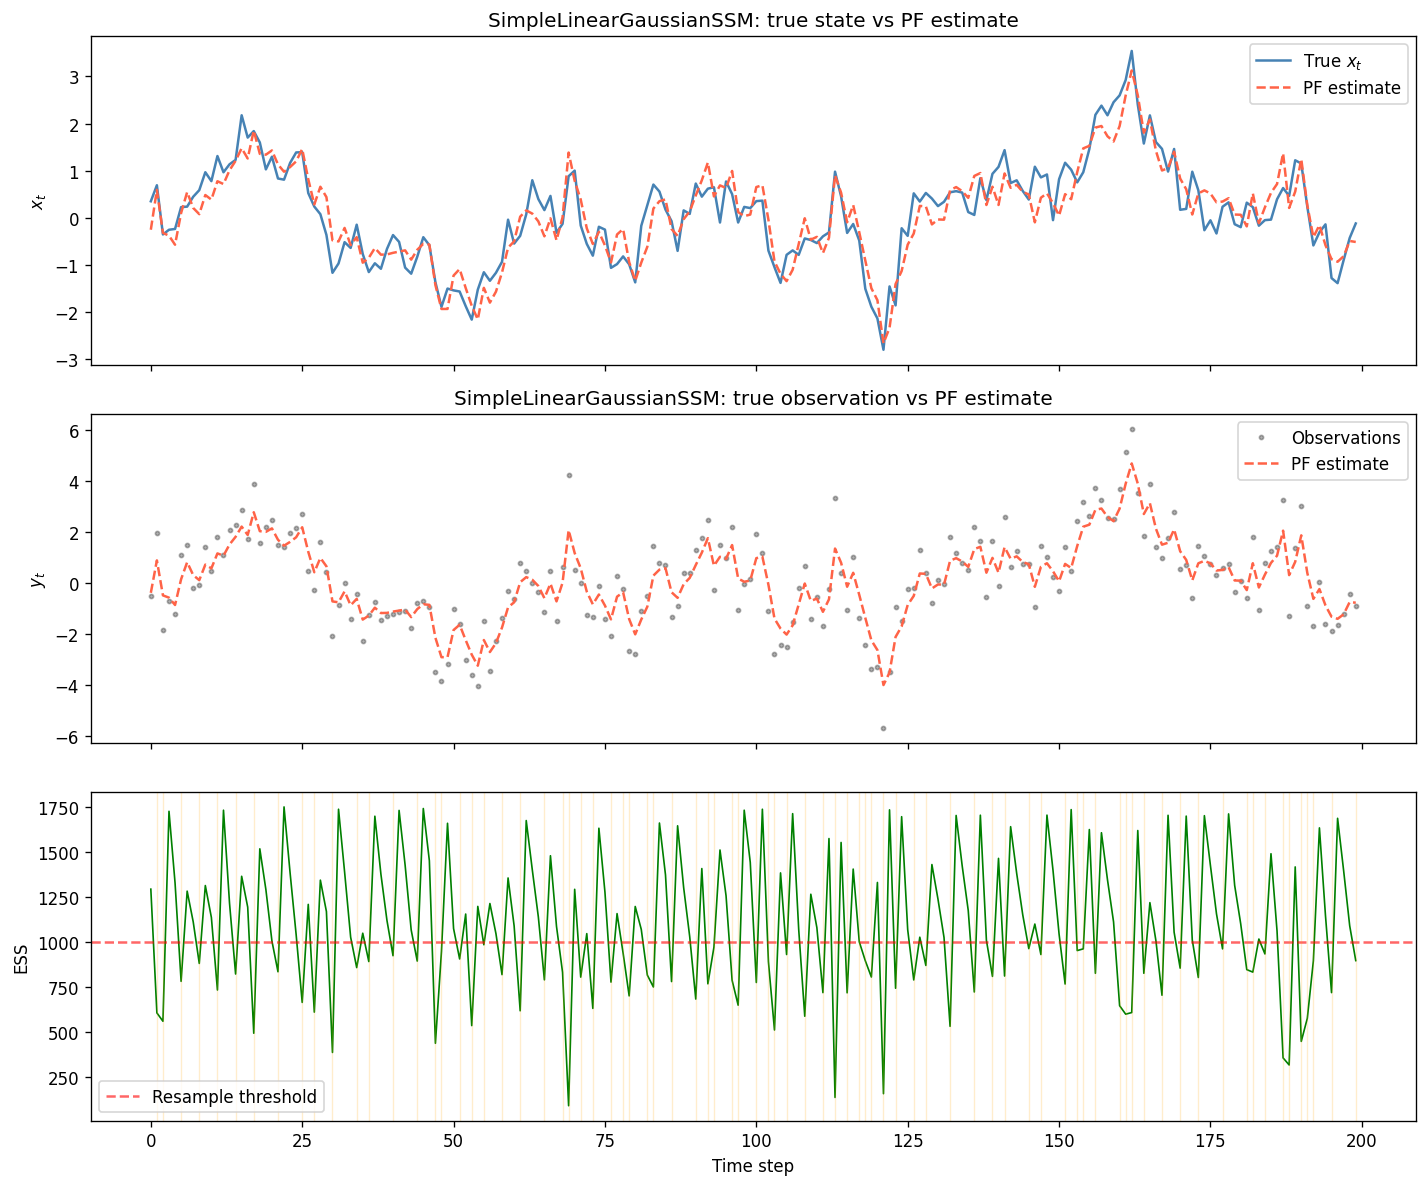

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(true_x, label='True $x_t$', color='steelblue', lw=1.5)
axes[0].plot(x_hat,  label='PF estimate', color='tomato', lw=1.5, linestyle='--')
axes[0].set_ylabel('$x_t$')
axes[0].legend()
axes[0].set_title('SimpleLinearGaussianSSM: true state vs PF estimate')

axes[1].plot(obs_1d, '.', color='black', markersize=5, alpha=0.3, label='Observations')
axes[1].plot(alpha_true * x_hat, label='PF estimate', color='tomato', lw=1.5, linestyle='--')
axes[1].set_ylabel('$y_t$')
axes[1].legend()
axes[1].set_title('SimpleLinearGaussianSSM: true observation vs PF estimate')

ess = ess_trajectory(pf)
axes[2].plot(ess, color='green', lw=1)
axes[2].axhline(pf.resample_threshold * pf.N_particles, color='red',
                linestyle='--', alpha=0.6, label='Resample threshold')
for s in [i for i, r in enumerate(rsh) if r]:
    axes[2].axvline(s, color='orange', alpha=0.2, lw=0.8)
axes[2].set_ylabel('ESS')
axes[2].set_xlabel('Time step')
axes[2].legend()
plt.tight_layout()
plt.show()

---
## 2. MC RMSE and log-likelihood distribution (50 trials)

In [ ]:
N_trials = 50
T_mc = 150
N_mc  = 1000

rmse_mc   = []
loglik_mc = []

for seed in range(N_trials):
    m = SimpleLinearGaussianSSM(phi=phi_true, alpha=alpha_true,
                                sigma2=sigma2_true, tau2=tau2_true, seed=seed)
    s, o, _ = m.generate_data(T_mc)
    pf_ = ParticleFilter(model=m, N_particles=N_mc, data=o[:, 0],
                         resample_method=SystematicResampling(seed=seed + 1000))
    _, ph_, wh_, _, ll = pf_.run_filter(verbose=False)
    x_hat_ = filtered_trajectory(pf_)
    rmse_mc.append(rmse(s[:, 0], x_hat_))
    loglik_mc.append(ll)

print(f"RMSE   : {np.mean(rmse_mc):.4f} ± {np.std(rmse_mc):.4f}")
print(f"Log-lik: {np.mean(loglik_mc):.2f} ± {np.std(loglik_mc):.2f}")


ParticleFilter.run_filter  1.684s
ParticleFilter.run_filter  1.367s
ParticleFilter.run_filter  1.135s
ParticleFilter.run_filter  1.391s
ParticleFilter.run_filter  1.199s
ParticleFilter.run_filter  1.165s
ParticleFilter.run_filter  1.240s
ParticleFilter.run_filter  1.138s
ParticleFilter.run_filter  1.301s
ParticleFilter.run_filter  1.179s
ParticleFilter.run_filter  1.135s
ParticleFilter.run_filter  1.131s
ParticleFilter.run_filter  1.209s
ParticleFilter.run_filter  1.184s
ParticleFilter.run_filter  1.257s
ParticleFilter.run_filter  1.186s
ParticleFilter.run_filter  1.333s
ParticleFilter.run_filter  1.132s
ParticleFilter.run_filter  1.130s
ParticleFilter.run_filter  1.307s
ParticleFilter.run_filter  1.171s
ParticleFilter.run_filter  1.178s
ParticleFilter.run_filter  1.264s
ParticleFilter.run_filter  1.370s
ParticleFilter.run_filter  1.187s
ParticleFilter.run_filter  1.140s
ParticleFilter.run_filter  1.578s
ParticleFilter.run_filter  1.202s
ParticleFilter.run_filter  1.175s
ParticleFilter

KeyboardInterrupt: 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(rmse_mc, bins=15, color='steelblue', edgecolor='white')
axes[0].axvline(np.mean(rmse_mc), color='red', linestyle='--', label=f'Mean={np.mean(rmse_mc):.3f}')
axes[0].set_xlabel('RMSE')
axes[0].set_title(f'RMSE distribution ({N_trials} trials)')
axes[0].legend()

axes[1].hist(loglik_mc, bins=15, color='coral', edgecolor='white')
axes[1].axvline(np.mean(loglik_mc), color='navy', linestyle='--', label=f'Mean={np.mean(loglik_mc):.1f}')
axes[1].set_xlabel('Log-likelihood')
axes[1].set_title('Log-likelihood distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 3. Effect of N_particles on filtering accuracy

In [ ]:
# Fixed dataset: same true states and observations for every run so that
# differences come from particle stochasticity only, not data variation.
model_ref = SimpleLinearGaussianSSM(phi=phi_true, alpha=alpha_true,
                                    sigma2=sigma2_true, tau2=tau2_true, seed=0)
states_ref, obs_ref, _ = model_ref.generate_data(150)
obs_ref_1d = obs_ref[:, 0]
true_x_ref = states_ref[:, 0]

N_values = [25, 50, 100, 250, 500, 1000, 2500, 5000, 10000, 20000]
N_reps   = 30

rmse_by_N   = {n: [] for n in N_values}
loglik_by_N = {n: [] for n in N_values}

for N_p in N_values:
    for rep in range(N_reps):
        pf_n = ParticleFilter(model=model_ref, N_particles=N_p, data=obs_ref_1d,
                              resample_method=SystematicResampling(seed=rep))
        _, _, _, _, ll_n = pf_n.run_filter()
        rmse_by_N[N_p].append(rmse(true_x_ref, filtered_trajectory(pf_n)))
        loglik_by_N[N_p].append(ll_n)
    print(f"N={N_p:6d}  RMSE={np.mean(rmse_by_N[N_p]):.4f} ± {np.std(rmse_by_N[N_p]):.4f}"
          f"  loglik={np.mean(loglik_by_N[N_p]):.2f} ± {np.std(loglik_by_N[N_p]):.2f}")


In [ ]:
# true log-likelihood
loglik_true = model_ref.log_likelihood(obs_ref_1d)
print(f"True log-likelihood: {loglik_true:.2f}")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── RMSE mean ± 1 std ──────────────────────────────────────────────────────
axes[0].semilogx(N_values, rmse_mean, 'o-', color='steelblue', lw=2, label='Mean RMSE')
axes[0].fill_between(N_values, rmse_mean - rmse_std, rmse_mean + rmse_std,
                     alpha=0.25, color='steelblue', label='±1 std')
axes[0].set_xlabel('N particles (log scale)')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Filtering accuracy vs N particles')
axes[0].legend()

# ── log-likelihood mean ± 1 std ────────────────────────────────────────────
axes[1].semilogx(N_values, loglik_mean, 'o-', color='coral', lw=2, label='Mean log-lik')
axes[1].fill_between(N_values, loglik_mean - loglik_std, loglik_mean + loglik_std,
                     alpha=0.25, color='coral', label='±1 std')
# plot true log-likelihood of data as a constant line
axes[1].semilogx(N_values, loglik_true * np.ones(len(N_values)), '-', color='red', lw=2, label='True log-lik')
axes[1].set_xlabel('N particles (log scale)')
axes[1].set_ylabel('Log-likelihood estimate')
axes[1].set_title('Log-likelihood estimate vs N particles')
axes[1].legend()

# ── log-likelihood std on log-log (should scale as 1/sqrt(N)) ─────────────
axes[2].loglog(N_values, loglik_std, 'o-', color='purple', lw=2, label='Std of log-lik')
# reference 1/sqrt(N) line anchored at the largest N
ref_scale = loglik_std[-1] * np.sqrt(N_values[-1])
ref_line  = ref_scale / np.sqrt(N_values)
axes[2].loglog(N_values, ref_line, '--', color='gray', lw=1.5, label='$1/\\sqrt{N}$ reference')
axes[2].set_xlabel('N particles (log scale)')
axes[2].set_ylabel('Std of log-likelihood (log scale)')
axes[2].set_title('Log-lik variance vs N (log-log)')
axes[2].legend()

plt.tight_layout()
plt.show()

---
## 4. Noise sensitivity: effect of σ and τ on filtering accuracy

In [ ]:
def mean_and_std_rmse(phi, alpha, sigma, tau, n_trials=15, T=100, N=500):
    """sigma and tau are std devs; internally converted to variances for the model."""
    errors = []
    for seed in range(n_trials):
        m = SimpleLinearGaussianSSM(phi=phi, alpha=alpha,
                                    sigma2=sigma**2, tau2=tau**2, seed=seed)
        s, o, _ = m.generate_data(T)
        pf_ = ParticleFilter(model=m, N_particles=N, data=o[:, 0],
                             resample_method=SystematicResampling(seed=seed + 500))
        pf_.run_filter()
        errors.append(rmse(s[:, 0], filtered_trajectory(pf_)))
    return np.mean(errors), np.std(errors)

sigma_vals = [0.1, 0.3, 0.5, 0.8, 1.2, 2.0, 3.0]
tau_vals   = [0.3, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0]

sigma_results = [mean_and_std_rmse(0.9, 1.0, s, 1.0) for s in sigma_vals]
tau_results   = [mean_and_std_rmse(0.9, 1.0, 0.5, t) for t in tau_vals]

sigma_mean, sigma_std = map(np.array, zip(*sigma_results))
tau_mean,   tau_std   = map(np.array, zip(*tau_results))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(sigma_vals, sigma_mean, 'o-', color='steelblue', lw=2, label='Mean RMSE')
axes[0].fill_between(sigma_vals, sigma_mean - sigma_std, sigma_mean + sigma_std,
                     alpha=0.25, color='steelblue', label='±1 std')
axes[0].set_xlabel('Process noise σ')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Process noise vs filtering accuracy')
axes[0].legend()

axes[1].plot(tau_vals, tau_mean, 'o-', color='coral', lw=2, label='Mean RMSE')
axes[1].fill_between(tau_vals, tau_mean - tau_std, tau_mean + tau_std,
                     alpha=0.25, color='coral', label='±1 std')
axes[1].set_xlabel('Observation noise τ')
axes[1].set_ylabel('RMSE')
axes[1].set_title('Observation noise vs filtering accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
from models.linear_gaussian import LinearGaussianSSM
from estimation.kalman_filter import KalmanFilter

# Fix τ²=1.0, sweep σ so r = σ²/τ² ∈ [0.01, 9].  KF = exact RMSE lower bound.
phi_r   = 0.9
alpha_r = 1.0
tau_r   = 1.0
N_r     = 500
T_r     = 150
n_reps_r = 20

sigma_r_vals = np.logspace(-1, np.log10(3.0), 22)   # sigma 0.1 … 3.0
ratio_vals   = sigma_r_vals ** 2 / tau_r ** 2

pf_rmse_mean = np.zeros(len(sigma_r_vals))
pf_rmse_std  = np.zeros(len(sigma_r_vals))
kf_rmse_mean = np.zeros(len(sigma_r_vals))

rng_r = np.random.default_rng(77)

for i, sigma_r in enumerate(sigma_r_vals):
    pf_i, kf_i = [], []
    for rep in range(n_reps_r):
        seed_r = int(rng_r.integers(0, 10**6))
        m_r = SimpleLinearGaussianSSM(phi=phi_r, alpha=alpha_r,
                                      sigma2=sigma_r**2, tau2=tau_r**2, seed=seed_r)
        s_r, o_r, _ = m_r.generate_data(T_r)
        obs_r  = o_r[:, 0]
        true_r = s_r[:, 0]

        pf_r = ParticleFilter(model=m_r, N_particles=N_r, data=obs_r,
                              resample_method=SystematicResampling(seed=rep))
        pf_r.run_filter(verbose = False)
        pf_i.append(rmse(true_r, filtered_trajectory(pf_r)))

        kf_m = LinearGaussianSSM(
            a=np.array([[phi_r]]),
            c=np.array([[alpha_r]]),
            q=np.array([[sigma_r ** 2]]),
            r=np.array([[tau_r ** 2]]),
        )
        kf_r = KalmanFilter(model=kf_m, data=obs_r)
        filt_m, _, _ = kf_r.run_filter()
        kf_i.append(rmse(true_r, filt_m[:, 0]))

    pf_rmse_mean[i] = np.mean(pf_i)
    pf_rmse_std[i]  = np.std(pf_i)
    kf_rmse_mean[i] = np.mean(kf_i)

print(f"{'ratio':>8}  {'PF RMSE':>9}  {'KF RMSE':>9}  {'PF/KF':>7}")
print("-" * 38)
for i in range(len(sigma_r_vals)):
    print(f"{ratio_vals[i]:>8.3f}  {pf_rmse_mean[i]:>9.4f}  "
          f"{kf_rmse_mean[i]:>9.4f}  {pf_rmse_mean[i]/max(kf_rmse_mean[i],1e-9):>7.3f}")


### Results

- **Absolute RMSE scales with $\sigma$**: both PF and KF RMSE rise as the ratio grows because
  the latent state becomes more volatile — there is simply more to track.
- **KF sets the lower bound**: the Kalman filter is the exact posterior mean for this Gaussian
  model; any particle filter will have RMSE ≥ KF RMSE.
- **PF/KF efficiency is close to 1 across regimes** for N=500, but the gap widens at high
  ratios where the state jumps more per step, increasing degeneracy risk in the particle cloud.
  Increasing N narrows this gap (see Section 3).


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Left: absolute RMSE vs ratio ─────────────────────────────────────────────
ax = axes[0]
ax.plot(ratio_vals, pf_rmse_mean, 'o-', color='steelblue', lw=2, ms=4,
        label=f'PF  N={N_r}')
ax.fill_between(ratio_vals,
                pf_rmse_mean - pf_rmse_std, pf_rmse_mean + pf_rmse_std,
                alpha=0.2, color='steelblue', label='PF ±1 std')
ax.plot(ratio_vals, kf_rmse_mean, 's--', color='seagreen', lw=1.5, ms=4,
        label='Kalman filter (exact)')
ax.axvline(1.0, color='gray', ls=':', lw=1.2, label=r'$\sigma^2 = \tau^2$')
ax.set_xscale('log')
ax.set_xlabel(r'$\sigma^2 / \tau^2$  (process / obs variance ratio)', fontsize=11)
ax.set_ylabel('RMSE', fontsize=11)
ax.set_title(r'Absolute RMSE vs $\sigma^2/\tau^2$')
ax.legend(fontsize=8)

# ── Right: PF / KF relative efficiency ───────────────────────────────────────
ax2 = axes[1]
rel = pf_rmse_mean / np.maximum(kf_rmse_mean, 1e-12)
ax2.plot(ratio_vals, rel, 'o-', color='tomato', lw=2, ms=4)
ax2.axhline(1.0, color='seagreen', ls='--', lw=1.2, label='Kalman lower bound (1.0)')
ax2.axvline(1.0, color='gray', ls=':', lw=1.2, label=r'$\sigma^2 = \tau^2$')
ax2.set_xscale('log')
ax2.set_xlabel(r'$\sigma^2 / \tau^2$  (process / obs variance ratio)', fontsize=11)
ax2.set_ylabel('PF RMSE / KF RMSE', fontsize=11)
ax2.set_title(r'PF efficiency relative to Kalman filter')
ax2.legend(fontsize=8)

plt.suptitle(
    r'Effect of $\sigma^2/\tau^2$ ratio — '
    rf'$\phi={phi_r}$, $\alpha={alpha_r}$, $\tau^2={tau_r**2:.0f}$, N={N_r}',
    y=1.02, fontsize=10,
)
plt.tight_layout()
plt.show()


---
## 5. Empirical relation of N_particles vs observation noise τ

Fixes `phi=0.9`, `sigma2=0.25` (`sigma=0.5`), `alpha=1.0` and sweeps a grid of
`τ ∈ {0.5, 1.0, 1.5, 2.0, 3.0, 5.0, 7.0}` × `N ∈ {50 … 20 000}` (9 levels).
Datasets are pre-generated once per `(τ, seed)` pair so the same data is used at every N,
isolating the effect of particle count from data variation.

For each `(τ, N)` cell, 20 independent PF runs are averaged to estimate:
- **mean and std RMSE** of the filtered state estimate
- **mean and std log-likelihood** estimate from the PF


In [ ]:
tau_vals = [0.5, 1.0, 1.5, 2.0, 3.0, 5.0, 7.0]
N_vals   = [50, 100, 250, 500, 1000, 2500, 5000, 10000, 20000]
n_reps   = 20
T_grid   = 100

# Pre-generate datasets once per (tau, seed) — reused across all N values
# so RMSE/loglik differences reflect particle count only, not data variation.
all_datasets = {}        # {(tau_idx, seed): (model, states, obs)}
true_logliks = np.zeros((len(tau_vals), n_reps))

for i, tau in enumerate(tau_vals):
    for seed in range(n_reps):
        m = SimpleLinearGaussianSSM(phi=0.9, alpha=1.0, sigma2=0.25, tau2=tau**2, seed=seed)
        s, o, _ = m.generate_data(T_grid)
        all_datasets[(i, seed)] = (m, s, o)
        true_logliks[i, seed] = m.log_likelihood(o[:, 0])

true_loglik_by_tau = true_logliks.mean(axis=1)

# Grid sweep
rmse_grid       = np.zeros((len(tau_vals), len(N_vals)))
rmse_std_grid   = np.zeros_like(rmse_grid)
loglik_grid     = np.zeros_like(rmse_grid)
loglik_std_grid = np.zeros_like(rmse_grid)

for i, tau in enumerate(tau_vals):
    for j, N in enumerate(N_vals):
        errors, logliks = [], []
        for seed in range(n_reps):
            m, s, o = all_datasets[(i, seed)]
            pf_ = ParticleFilter(
                model=m, N_particles=N, data=o[:, 0],
                resample_method=SystematicResampling(seed=seed + 500),
                seed=seed + 1000,
            )
            _, _, _, _, ll = pf_.run_filter()
            errors.append(rmse(s[:, 0], filtered_trajectory(pf_)))
            logliks.append(ll)
        rmse_grid[i, j]       = np.mean(errors)
        rmse_std_grid[i, j]   = np.std(errors)
        loglik_grid[i, j]     = np.mean(logliks)
        loglik_std_grid[i, j] = np.std(logliks)
    print(f"  tau={tau:.1f}  RMSE: {rmse_grid[i]}  true loglik: {true_loglik_by_tau[i]:.2f}")

print("Done.")

In [ ]:
from models.linear_gaussian import LinearGaussianSSM
from estimation.kalman_filter import KalmanFilter

# Run the Kalman filter on the same pre-generated datasets.
# KalmanFilter requires LinearGaussianSSM, so we wrap the 1D parameters.
kf_rmse_by_tau   = np.zeros(len(tau_vals))
kf_loglik_by_tau = np.zeros(len(tau_vals))

for i, tau in enumerate(tau_vals):
    kf_rmse_list, kf_loglik_list = [], []
    for seed in range(n_reps):
        m, s, o = all_datasets[(i, seed)]
        mg = LinearGaussianSSM(
            a=np.array([[m.phi]]),
            c=np.array([[m.alpha]]),
            q=np.array([[m.sigma2]]),
            r=np.array([[m.tau2]]),
        )
        kf = KalmanFilter(model=mg, data=o[:, 0])
        filt_means, _, kf_ll = kf.run_filter()
        kf_rmse_list.append(rmse(s[:, 0], filt_means[:, 0]))
        kf_loglik_list.append(kf_ll)
    kf_rmse_by_tau[i]   = np.mean(kf_rmse_list)
    kf_loglik_by_tau[i] = np.mean(kf_loglik_list)

print(f"{'tau':>5}  {'KF RMSE':>9}  {'KF loglik':>10}  {'true loglik':>12}")
print("-" * 44)
for i, tau in enumerate(tau_vals):
    print(f"{tau:>5.1f}  {kf_rmse_by_tau[i]:>9.4f}  {kf_loglik_by_tau[i]:>10.2f}  "
          f"{true_loglik_by_tau[i]:>12.2f}")

In [ ]:
# ── mean RMSE table ───────────────────────────────────────────────────────────
header = f"{'tau':>5}  " + "  ".join(f"N={n:>5}" for n in N_vals) + f"  {'KF':>7}"
print("Mean RMSE")
print(header)
print("-" * len(header))
for i, tau in enumerate(tau_vals):
    row = (f"{tau:>5.1f}  "
           + "  ".join(f"{rmse_grid[i, j]:>7.4f}" for j in range(len(N_vals)))
           + f"  {kf_rmse_by_tau[i]:>7.4f}")
    print(row)

# ── mean PF log-likelihood table (vs true) ────────────────────────────────────
print("\nMean PF log-likelihood  (true = KF log-lik)")
header2 = f"{'tau':>5}  " + "  ".join(f"N={n:>5}" for n in N_vals) + f"  {'true':>9}"
print(header2)
print("-" * len(header2))
for i, tau in enumerate(tau_vals):
    row = (f"{tau:>5.1f}  "
           + "  ".join(f"{loglik_grid[i, j]:>7.2f}" for j in range(len(N_vals)))
           + f"  {true_loglik_by_tau[i]:>9.2f}")
    print(row)

# ── minimum N to approach the KF RMSE floor ───────────────────────────────────
# target: within 5% of the KF floor for each tau level
print("\nMin N to reach within 5% of KF RMSE floor")
print(f"{'tau':>5}  {'KF floor':>9}  {'target':>8}  {'min N':>6}")
print("-" * 36)
for i, tau in enumerate(tau_vals):
    target = kf_rmse_by_tau[i] * 1.05
    hit = [N_vals[j] for j in range(len(N_vals)) if rmse_grid[i, j] <= target]
    min_n = str(min(hit)) if hit else f">{N_vals[-1]}"
    print(f"{tau:>5.1f}  {kf_rmse_by_tau[i]:>9.4f}  {target:>8.4f}  {min_n:>6}")

In [ ]:
tau_labels = [str(t) for t in tau_vals]
N_labels   = [str(n) for n in N_vals]
cmap_tau   = plt.cm.plasma
colors     = [cmap_tau(k / (len(tau_vals) - 1)) for k in range(len(tau_vals))]

fig, axes = plt.subplots(2, 3, figsize=(17, 9))

# ── [0,0] heatmap: mean RMSE ──────────────────────────────────────────────────
im0 = axes[0, 0].imshow(rmse_grid, aspect='auto', cmap='YlOrRd')
axes[0, 0].set_xticks(range(len(N_vals)));   axes[0, 0].set_xticklabels(N_labels, rotation=45)
axes[0, 0].set_yticks(range(len(tau_vals))); axes[0, 0].set_yticklabels(tau_labels)
axes[0, 0].set_xlabel('N particles');  axes[0, 0].set_ylabel('τ')
axes[0, 0].set_title('Mean RMSE (τ × N)')
fig.colorbar(im0, ax=axes[0, 0])
for i in range(len(tau_vals)):
    for j in range(len(N_vals)):
        axes[0, 0].text(j, i, f'{rmse_grid[i, j]:.3f}', ha='center', va='center',
                        fontsize=6, color='white' if rmse_grid[i, j] > rmse_grid.mean() else 'black')

# ── [0,1] per-tau RMSE vs N with KF floor ─────────────────────────────────────
for i, (tau, col) in enumerate(zip(tau_vals, colors)):
    axes[0, 1].semilogx(N_vals, rmse_grid[i], 'o-', color=col, lw=2, label=f'τ={tau}')
    axes[0, 1].fill_between(N_vals,
                             rmse_grid[i] - rmse_std_grid[i],
                             rmse_grid[i] + rmse_std_grid[i],
                             alpha=0.12, color=col)
    axes[0, 1].axhline(kf_rmse_by_tau[i], color=col, lw=1, linestyle=':')
axes[0, 1].set_xlabel('N particles (log scale)'); axes[0, 1].set_ylabel('Mean RMSE')
axes[0, 1].set_title('RMSE vs N  (dotted = KF floor)')
axes[0, 1].legend(fontsize=7, loc='upper right')

# ── [0,2] heatmap: std RMSE ───────────────────────────────────────────────────
im2 = axes[0, 2].imshow(rmse_std_grid, aspect='auto', cmap='Blues')
axes[0, 2].set_xticks(range(len(N_vals)));   axes[0, 2].set_xticklabels(N_labels, rotation=45)
axes[0, 2].set_yticks(range(len(tau_vals))); axes[0, 2].set_yticklabels(tau_labels)
axes[0, 2].set_xlabel('N particles');  axes[0, 2].set_ylabel('τ')
axes[0, 2].set_title('Std RMSE (τ × N)')
fig.colorbar(im2, ax=axes[0, 2])
for i in range(len(tau_vals)):
    for j in range(len(N_vals)):
        axes[0, 2].text(j, i, f'{rmse_std_grid[i, j]:.3f}', ha='center', va='center',
                        fontsize=6, color='white' if rmse_std_grid[i, j] > rmse_std_grid.mean() else 'black')

# ── [1,0] heatmap: mean loglik bias (PF - true) ───────────────────────────────
loglik_bias = loglik_grid - true_loglik_by_tau[:, None]
vmax = np.max(np.abs(loglik_bias))
im3 = axes[1, 0].imshow(loglik_bias, aspect='auto', cmap='RdBu', vmin=-vmax, vmax=vmax)
axes[1, 0].set_xticks(range(len(N_vals)));   axes[1, 0].set_xticklabels(N_labels, rotation=45)
axes[1, 0].set_yticks(range(len(tau_vals))); axes[1, 0].set_yticklabels(tau_labels)
axes[1, 0].set_xlabel('N particles');  axes[1, 0].set_ylabel('τ')
axes[1, 0].set_title('PF log-lik bias  (PF − true)')
fig.colorbar(im3, ax=axes[1, 0])
for i in range(len(tau_vals)):
    for j in range(len(N_vals)):
        axes[1, 0].text(j, i, f'{loglik_bias[i, j]:.1f}', ha='center', va='center',
                        fontsize=6, color='black')

# ── [1,1] per-tau loglik estimate vs N with true loglik reference ─────────────
for i, (tau, col) in enumerate(zip(tau_vals, colors)):
    axes[1, 1].semilogx(N_vals, loglik_grid[i], 'o-', color=col, lw=2, label=f'τ={tau}')
    axes[1, 1].fill_between(N_vals,
                             loglik_grid[i] - loglik_std_grid[i],
                             loglik_grid[i] + loglik_std_grid[i],
                             alpha=0.12, color=col)
    axes[1, 1].axhline(true_loglik_by_tau[i], color=col, lw=1, linestyle=':')
axes[1, 1].set_xlabel('N particles (log scale)'); axes[1, 1].set_ylabel('Mean log-likelihood')
axes[1, 1].set_title('PF log-lik vs N  (dotted = true)')
axes[1, 1].legend(fontsize=7, loc='lower right')

# ── [1,2] PF RMSE floor vs KF RMSE, by tau ───────────────────────────────────
pf_floor = rmse_grid[:, -1]   # N=20000 as the PF floor
x = np.arange(len(tau_vals))
w = 0.35
axes[1, 2].bar(x - w/2, kf_rmse_by_tau, width=w, label='Kalman filter', color='steelblue')
axes[1, 2].bar(x + w/2, pf_floor,        width=w, label='PF (N=20 000)', color='coral')
axes[1, 2].set_xticks(x); axes[1, 2].set_xticklabels(tau_labels)
axes[1, 2].set_xlabel('τ');  axes[1, 2].set_ylabel('Mean RMSE')
axes[1, 2].set_title('KF vs PF floor by τ')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

### Results

**1. Mean RMSE is set by τ, not N.**
For every τ level the mean RMSE is essentially flat across the full N range (50 → 20 000).
Increasing particle count produces negligible improvement in average accuracy — the dominant error
source is the posterior uncertainty from observation noise, not particle approximation error.

**2. RMSE tracks the Kalman filter floor at all N.**
The KF vs PF floor chart shows that even at N=50 the PF mean RMSE is within a few percent of
the optimal Kalman filter — confirming the filter is well-calibrated and that the residual gap
is purely statistical, not computational.

**3. RMSE saturates at high τ (information saturation).**
RMSE grows steeply from τ=0.5 to τ=3.0, then plateaus: τ=5.0 and τ=7.0 produce nearly identical
errors. Once observations are sufficiently noisy they convey almost no information about the latent
state, and the posterior is dominated by the prior dynamics.

**4. N controls variance, not mean error.**
The std-RMSE heatmap shows a consistent decrease with N at all τ. More particles yield more
reproducible runs — useful when PMMH or other downstream inference requires a stable
log-likelihood estimate.

**5. PF log-likelihood bias shrinks with N and is small at moderate N.**
The bias heatmap (PF − true) shows that at low N the PF underestimates the true log-likelihood
(negative bias), consistent with Jensen's inequality for concave log. By N≈500 the bias is
negligible for all τ levels, confirming that N=500–1000 is sufficient for unbiased PMMH proposals
on this model.

---
## 6. Resampling method comparison

In [ ]:
resamplers = {
    'Systematic' : SystematicResampling,
    'Stratified' : StratifiedResampling,
    'Residual'   : ResidualResampling,
    'Multinomial': MultinomialResampling,
}

N_rs   = 30
T_rs   = 100
N_part = 500

rmse_rs   = {k: [] for k in resamplers}
loglik_rs = {k: [] for k in resamplers}

for seed in range(N_rs):
    m = SimpleLinearGaussianSSM(phi=0.9, alpha=1.0, sigma2=0.25, tau2=1.0, seed=seed)
    s, o, _ = m.generate_data(T_rs)
    for name, cls in resamplers.items():
        pf_ = ParticleFilter(model=m, N_particles=N_part, data=o[:, 0],
                             resample_method=cls(seed=seed + 2000), seed=seed + 3000)
        _, ph_, wh_, _, ll = pf_.run_filter()
        rmse_rs[name].append(rmse(s[:, 0], filtered_trajectory(pf_)))
        loglik_rs[name].append(ll)

In [ ]:
results = {
    name: (np.mean(rmse_rs[name]), np.std(rmse_rs[name]),
           np.mean(loglik_rs[name]), np.std(loglik_rs[name]))
    for name in resamplers
}

best = {
    0: min(results, key=lambda x: results[x][0]),  # lowest RMSE mean
    1: min(results, key=lambda x: results[x][1]),  # lowest RMSE std
    2: max(results, key=lambda x: results[x][2]),  # highest loglik mean
    3: min(results, key=lambda x: results[x][3]),  # lowest loglik std
}

def star(name, col):
    return '★' if best[col] == name else ' '

print(f"{'Method':<12}  {'RMSE mean':>10}  {'RMSE std':>9}  {'loglik mean':>12}  {'loglik std':>10}")
print('-' * 60)
for name, (rm, rs, lm, ls) in results.items():
    print(f"{name:<12}  {rm:>9.4f}{star(name,0)}  {rs:>8.4f}{star(name,1)}  "
          f"{lm:>11.2f}{star(name,2)}  {ls:>9.2f}{star(name,3)}")

In [ ]:
names = list(resamplers.keys())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot([rmse_rs[n] for n in names], labels=names)
axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE by resampling method')

axes[1].boxplot([loglik_rs[n] for n in names], labels=names)
axes[1].set_ylabel('Log-likelihood estimate')
axes[1].set_title('Log-likelihood by resampling method')

plt.tight_layout()
plt.show()

---
## 7. LinearTSSM — correct vs misspecified filter

Data generated from a model with t-distributed process noise (df=5).  
Compare PF using the correct `LinearTSSM` against a misspecified `SimpleLinearGaussianSSM` filter.

In [ ]:
model_t = LinearTSSM(alpha=1.0, tau=1.0, phi=0.9, sigma=0.5, df=5, seed=42)
print(model_t)

T_t = 200
states_t, obs_t, _ = model_t.generate_data(T_t)
obs_t_1d = obs_t[:, 0]
true_x_t = states_t[:, 0]

# correct model
pf_t_correct = ParticleFilter(
    model=LinearTSSM(alpha=1.0, tau=1.0, phi=0.9, sigma=0.5, df=5, seed=1),
    N_particles=2000, data=obs_t_1d,
    resample_method=SystematicResampling(seed=10)
)
_, _, _, _, ll_correct = pf_t_correct.run_filter()
x_correct = filtered_trajectory(pf_t_correct)

# misspecified Gaussian filter
pf_t_misspec = ParticleFilter(
    model=SimpleLinearGaussianSSM(phi=0.9, alpha=1.0, sigma2=0.25, tau2=1.0, seed=1),
    N_particles=2000, data=obs_t_1d,
    resample_method=SystematicResampling(seed=10)
)
_, _, _, _, ll_misspec = pf_t_misspec.run_filter()
x_misspec = filtered_trajectory(pf_t_misspec)

print(f"t-SSM  (correct)     loglik={ll_correct:.2f}  RMSE={rmse(true_x_t, x_correct):.4f}")
print(f"Gauss  (misspecified) loglik={ll_misspec:.2f}  RMSE={rmse(true_x_t, x_misspec):.4f}")

In [ ]:
N_t = 30
T_t_mc = 100
N_t_part = 1000

rmse_correct_t  = []
rmse_misspec_t  = []

for seed in range(N_t):
    m_t = LinearTSSM(alpha=1.0, tau=1.0, phi=0.9, sigma=0.5, df=5, seed=seed)
    s_t, o_t, _ = m_t.generate_data(T_t_mc)
    obs_flat = o_t[:, 0]

    pf_c = ParticleFilter(
        model=LinearTSSM(alpha=1.0, tau=1.0, phi=0.9, sigma=0.5, df=5, seed=seed + 100),
        N_particles=N_t_part, data=obs_flat,
        resample_method=SystematicResampling(seed=seed + 200)
    )
    pf_c.run_filter()
    rmse_correct_t.append(rmse(s_t[:, 0], filtered_trajectory(pf_c)))

    pf_m = ParticleFilter(
        model=SimpleLinearGaussianSSM(phi=0.9, alpha=1.0, sigma2=0.25, tau2=1.0, seed=seed + 100),
        N_particles=N_t_part, data=obs_flat,
        resample_method=SystematicResampling(seed=seed + 300)
    )
    pf_m.run_filter()
    rmse_misspec_t.append(rmse(s_t[:, 0], filtered_trajectory(pf_m)))

print(f"t-SSM   RMSE: {np.mean(rmse_correct_t):.4f} ± {np.std(rmse_correct_t):.4f}")
print(f"Gauss   RMSE: {np.mean(rmse_misspec_t):.4f} ± {np.std(rmse_misspec_t):.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot([rmse_correct_t, rmse_misspec_t],
           labels=['t-SSM (correct)', 'Gaussian (misspecified)'])
ax.set_ylabel('RMSE')
ax.set_title('Model misspecification: t-distributed data')
plt.tight_layout()
plt.show()

---
## 8. LinearARMASSM (correct vs misspecified filter)

Latent process: $x_t = c + \phi x_{t-1} + \nu_t + \theta_1 \nu_{t-1} + \theta_2 \nu_{t-2} + \theta_3 \nu_{t-3}$.  
Markov state: $s_t = [x_t,\, \nu_{t-1},\, \nu_{t-2}, \, \nu_{t-3}]^\top$. PF estimates the full 4D state; we compare on the $x_t$ component.

In [ ]:
model_arma = LinearARMASSM(
    phi=0.8, alpha=1.0, c=0.0,
    theta_1=0.3, theta_2=0.2, theta_3=0.1,
    sigma=0.5, tau=1.0, seed=42
)
print(model_arma)

T_arma = 200
states_arma, obs_arma, _ = model_arma.generate_data(T_arma)
obs_arma_1d = obs_arma[:, 0]
true_x_arma = states_arma[:, 0]

pf_arma = ParticleFilter(
    model=model_arma, N_particles=3000, data=obs_arma_1d,
    resample_method=SystematicResampling(seed=5)
)

pf_arma_misspec = ParticleFilter(
    model=SimpleLinearGaussianSSM(phi=0.8, alpha=1.0, sigma2=0.25, tau2=1.0, seed=42),
    N_particles=3000, data=obs_arma_1d,
    resample_method=SystematicResampling(seed=5)
)

_, ph_arma, wh_arma, rsh_arma, loglik_arma = pf_arma.run_filter()
_, ph_arma_misspec, wh_arma_misspec, rsh_arma_misspec, loglik_arma_misspec = pf_arma_misspec.run_filter()

x_hat_arma = filtered_trajectory(pf_arma, state_idx=0)
x_hat_arma_misspec = filtered_trajectory(pf_arma_misspec, state_idx=0)

print(f"ARMA PF log-likelihood: {loglik_arma:.2f}")
print(f"RMSE (x_t component)  : {rmse(true_x_arma, x_hat_arma):.4f}")
print(f"Resample steps        : {sum(rsh_arma)} / {T_arma}")
print("---"*30)
print("Misspecified linear model results:")
print(f"ARMA PF log-likelihood: {loglik_arma_misspec:.2f}")
print(f"RMSE (x_t component)  : {rmse(true_x_arma, x_hat_arma_misspec):.4f}")
print(f"Resample steps        : {sum(rsh_arma_misspec)} / {T_arma}")

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

axes[0].plot(true_x_arma,  label='True $x_t$', color='steelblue', lw=1.5)
axes[0].plot(x_hat_arma,   label='PF estimate', color='tomato', lw=1.5, linestyle='--')
axes[0].plot(obs_arma_1d,  '.', color='black', markersize=2, alpha=0.3, label='Observations')
axes[0].set_ylabel('$x_t$')
axes[0].legend()
axes[0].set_title('LinearARMASSM: true $x_t$ vs PF estimate')

ess_arma = ess_trajectory(pf_arma)
axes[1].plot(ess_arma, color='green', lw=1)
axes[1].axhline(pf_arma.resample_threshold * pf_arma.N_particles,
                color='red', linestyle='--', alpha=0.6, label='Resample threshold')
axes[1].set_ylabel('ESS')
axes[1].set_xlabel('Time step')
axes[1].legend()

axes[2].plot(true_x_arma,  label='True $x_t$', color='steelblue', lw=1.5)
axes[2].plot(x_hat_arma_misspec, label='Misspecified PF estimate', color='tomato', lw=1.5, linestyle='--')
axes[2].plot(obs_arma_1d,  '.', color='black', markersize=2, alpha=0.3, label='Observations')
axes[2].set_ylabel('$x_t$')
axes[2].legend()
axes[2].set_title('SimpleLinearGaussianSSM: true $x_t$ from LinearARMA vs Misspecified PF estimate')

ess_arma_misspec = ess_trajectory(pf_arma_misspec)
axes[3].plot(ess_arma_misspec, color='green', lw=1)
axes[3].axhline(pf_arma.resample_threshold * pf_arma.N_particles,
                color='red', linestyle='--', alpha=0.6, label='Resample threshold')
axes[3].set_ylabel('ESS')
axes[3].set_xlabel('Time step')
axes[3].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Comparing RMSE of the correct and missepcified models for ARMA

print(f"RMSE correct (x_t component)       : {rmse(true_x_arma, x_hat_arma):.4f}")
print(f"RMSE misspecified (x_t component)  : {rmse(true_x_arma, x_hat_arma_misspec):.4f}")


In [ ]:
# import from time_series_analysis.py to analyze ARMA(p,q) coefficients
from time_series_analysis import compare_arima_models

compare_arima_models(
    y = obs_arma_1d,
    p_values=range(0, 5),
    d_values=(0,),
    q_values=range(0, 5),
    max_ljungbox_lag=10,
    trend="n",
)

---
## Next steps

- **Kalman filter MLE**: for `SimpleLinearGaussianSSM`, the marginal log-likelihood is analytically tractable via the Kalman filter. Implement `kalman_log_likelihood(params, observations)` and optimize with `scipy.optimize.minimize`.
- **PMMH**: use the PF log-likelihood estimate as an unbiased estimator inside a Metropolis–Hastings loop to do Bayesian inference over `(phi, sigma, tau)`. The PF is already returning `loglik`.
- **RBPF / Kim filter**: for the regime-switching model in `src/models/regime_switching.py`, the Rao-Blackwellized PF marginalizes out the continuous state analytically while sampling discrete regimes.